In [1]:
from IPython.display import HTML
HTML('''<style>.jp-Cell-inputWrapper, .input { margin-top: 0.5em; }</style>''')

# Notebook 04 — Logistic Regression
## ENGG2112 Project MODR

This is the **first ML model** in the comparison study. Logistic regression serves as both a baseline and a candidate "production" model because:

1. **Outputs P(outbreak) directly** — feeds straight into the SIR simulation as a transmission rate modifier
2. **Coefficients are interpretable** — we can show *why* a county is high-risk (essential for the report)
3. **Policy levers compose well** — front-end sliders that modify a feature value yield smooth probability shifts
4. **Standard ML baseline** — comparison anchor for Notebooks 05–07

### Feature set (from Notebook 03)
- 8 demographic features: `pop_density_per_sqmi`, `pct_elderly`, `avg_household_size`, `median_income`, `public_transport_pct`, `pct_bachelors_plus`, `pct_non_white`, `pct_foreign_born`
- 3 state dummies: `state_DE`, `state_NY`, `state_PA` (CT = baseline reference)

### Modelling decisions
- **`class_weight='balanced'`** — outbreak rate is 26.2%, balanced weighting prevents the model collapsing to "always predict non-outbreak"
- **L2 regularisation** with cross-validated `C` — handles the multicollinearity flagged in Notebook 03 (Notebook 03 already explored L1/LASSO)
- **5-fold stratified cross-validation** — preserves outbreak rate per fold
- **Bootstrap coefficient CIs** (1000 resamples) — addresses the multicollinearity caveat by quantifying coefficient stability

### Evaluation
- Headline metric: **PR-AUC** (better than ROC-AUC for imbalanced classes — Saito & Rehmsmeier 2015)
- Calibration: Brier score + calibration curve (critical for SIR coupling)
- Out-of-fold predictions for honest performance estimates

### Outputs
- `models/lr_model.pkl` — fitted model artifact
- `models/lr_metrics.json` — performance + coefficients + bootstrap CIs

### References
- Hosmer, Lemeshow & Sturdivant (2013) — *Applied Logistic Regression*
- Niculescu-Mizil & Caruana (2005) — Probability calibration
- See `REFERENCES.md`

## 1. Setup

In [2]:
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve
)
from sklearn.calibration import calibration_curve

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.size': 11,
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_style('whitegrid')

# Load master + feature selection
master = pd.read_csv(PROCESSED_DIR / 'master_counties.csv', dtype={'fips': str, 'state_fips': str})
with open(PROCESSED_DIR / 'selected_features.json') as f:
    feature_config = json.load(f)

DEMOGRAPHIC_FEATURES = feature_config['demographic']
STATE_FEATURES = feature_config['state']
ALL_FEATURES = feature_config['all']

print(f'Cross-section: {master.shape}')
print(f'Demographic features ({len(DEMOGRAPHIC_FEATURES)}):')
for f in DEMOGRAPHIC_FEATURES:
    print(f'  • {f}')
print(f'\nState dummies ({len(STATE_FEATURES)}):')
for f in STATE_FEATURES:
    print(f'  • {f}')

Cross-section: (141, 38)
Demographic features (8):
  • pop_density_per_sqmi
  • pct_elderly
  • avg_household_size
  • median_income
  • public_transport_pct
  • pct_bachelors_plus
  • pct_non_white
  • pct_foreign_born

State dummies (3):
  • state_DE
  • state_NY
  • state_PA


## 2. Prepare Feature Matrix

Build X (features) and y (outbreak label). State dummies use CT as reference — DE, NY, PA dummies. Standardise demographic features (mean 0, variance 1) so coefficients are directly comparable in magnitude.

In [3]:
# Build state dummies (CT = reference)
state_dummies = pd.get_dummies(master['state'], prefix='state', drop_first=True).astype(float)

# Demographic features standardised; state dummies left as 0/1
scaler = StandardScaler()
X_demo_scaled = pd.DataFrame(
    scaler.fit_transform(master[DEMOGRAPHIC_FEATURES]),
    columns=DEMOGRAPHIC_FEATURES,
    index=master.index
)

X = pd.concat([X_demo_scaled, state_dummies], axis=1)
y = master['outbreak'].astype(int).values

print(f'Feature matrix: {X.shape}')
print(f'  Standardised demographic: {len(DEMOGRAPHIC_FEATURES)} cols')
print(f'  State dummies: {len(state_dummies.columns)} cols')
print(f'\nTarget balance: outbreak={y.sum()} ({y.mean():.1%}), non-outbreak={(y==0).sum()}')

# Save scaler for downstream use
with open(MODELS_DIR / 'lr_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

Feature matrix: (141, 11)
  Standardised demographic: 8 cols
  State dummies: 3 cols

Target balance: outbreak=37 (26.2%), non-outbreak=104


## 3. Train Model with Cross-Validation

Two complementary procedures:
1. **`LogisticRegressionCV`** picks optimal `C` (regularisation strength) via internal 5-fold CV. This becomes our **production model** trained on all 141 areas.
2. **Out-of-fold cross-validation** — we additionally compute honest, unbiased performance metrics by predicting on held-out folds.

In [4]:
# 3a. Production model — LogisticRegressionCV chooses C via internal CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = LogisticRegressionCV(
    Cs=20,
    cv=cv,
    penalty='l2',
    solver='lbfgs',
    class_weight='balanced',
    max_iter=2000,
    random_state=42,
    scoring='average_precision',  # PR-AUC — primary metric
    n_jobs=-1,
)
model.fit(X, y)

print(f'Selected C: {model.C_[0]:.4f}')
print(f'Coefficients fit on all {len(y)} observations')
print(f'\nMean inner-CV PR-AUC across all C values:')
for c, score in zip(model.Cs_, model.scores_[1].mean(axis=0)):
    marker = '  ← best' if c == model.C_[0] else ''
    print(f'  C={c:>7.4f}: PR-AUC = {score:.3f}{marker}')

Selected C: 0.0886
Coefficients fit on all 141 observations

Mean inner-CV PR-AUC across all C values:
  C= 0.0001: PR-AUC = 0.522
  C= 0.0003: PR-AUC = 0.520
  C= 0.0007: PR-AUC = 0.518
  C= 0.0018: PR-AUC = 0.521
  C= 0.0048: PR-AUC = 0.522
  C= 0.0127: PR-AUC = 0.543
  C= 0.0336: PR-AUC = 0.565
  C= 0.0886: PR-AUC = 0.574  ← best
  C= 0.2336: PR-AUC = 0.555
  C= 0.6158: PR-AUC = 0.541
  C= 1.6238: PR-AUC = 0.541
  C= 4.2813: PR-AUC = 0.549
  C=11.2884: PR-AUC = 0.550
  C=29.7635: PR-AUC = 0.548
  C=78.4760: PR-AUC = 0.542
  C=206.9138: PR-AUC = 0.548
  C=545.5595: PR-AUC = 0.548
  C=1438.4499: PR-AUC = 0.550
  C=3792.6902: PR-AUC = 0.550
  C=10000.0000: PR-AUC = 0.550


## 4. Out-of-Fold Predictions for Honest Metrics

`cross_val_predict` runs the same logistic regression across 5 stratified folds, giving us one prediction per area from a model that *did not see that area during training*. This is the proper way to estimate generalisation performance.

In [5]:
# Use the SAME C that was selected by LogisticRegressionCV — for consistency
cv_estimator = LogisticRegression(
    C=model.C_[0],
    penalty='l2',
    solver='lbfgs',
    class_weight='balanced',
    max_iter=2000,
    random_state=42,
)

# Out-of-fold predictions (probabilities)
oof_proba = cross_val_predict(cv_estimator, X, y, cv=cv, method='predict_proba')[:, 1]
oof_pred = (oof_proba >= 0.5).astype(int)

print(f'Out-of-fold predictions: {len(oof_proba)}')
print(f'Predicted positive: {oof_pred.sum()} ({oof_pred.mean():.1%})')

Out-of-fold predictions: 141
Predicted positive: 45 (31.9%)


## 5. Performance Metrics

All metrics computed on out-of-fold predictions (honest, no data leakage).

In [6]:
metrics = {
    'accuracy': accuracy_score(y, oof_pred),
    'precision': precision_score(y, oof_pred, zero_division=0),
    'recall': recall_score(y, oof_pred, zero_division=0),
    'f1': f1_score(y, oof_pred, zero_division=0),
    'roc_auc': roc_auc_score(y, oof_proba),
    'pr_auc': average_precision_score(y, oof_proba),  # ← headline
    'brier': brier_score_loss(y, oof_proba),
}

print('Cross-validated performance metrics:\n')
for k, v in metrics.items():
    marker = ' ← HEADLINE' if k == 'pr_auc' else ''
    print(f'  {k:<12s}: {v:.3f}{marker}')

# Baselines for context
positive_rate = y.mean()
print(f'\nBaselines for comparison:')
print(f'  Always-predict-zero accuracy: {1-positive_rate:.3f}')
print(f'  Random ROC-AUC:               0.500')
print(f'  Random PR-AUC:                {positive_rate:.3f}  (= positive rate)')

print(f'\n=== Classification report ===')
print(classification_report(y, oof_pred, target_names=['Non-outbreak', 'Outbreak']))

Cross-validated performance metrics:

  accuracy    : 0.631
  precision   : 0.333
  recall      : 0.405
  f1          : 0.366
  roc_auc     : 0.641
  pr_auc      : 0.500 ← HEADLINE
  brier       : 0.221

Baselines for comparison:
  Always-predict-zero accuracy: 0.738
  Random ROC-AUC:               0.500
  Random PR-AUC:                0.262  (= positive rate)

=== Classification report ===
              precision    recall  f1-score   support

Non-outbreak       0.77      0.71      0.74       104
    Outbreak       0.33      0.41      0.37        37

    accuracy                           0.63       141
   macro avg       0.55      0.56      0.55       141
weighted avg       0.66      0.63      0.64       141



## 6. Confusion Matrix, ROC, PR Curve

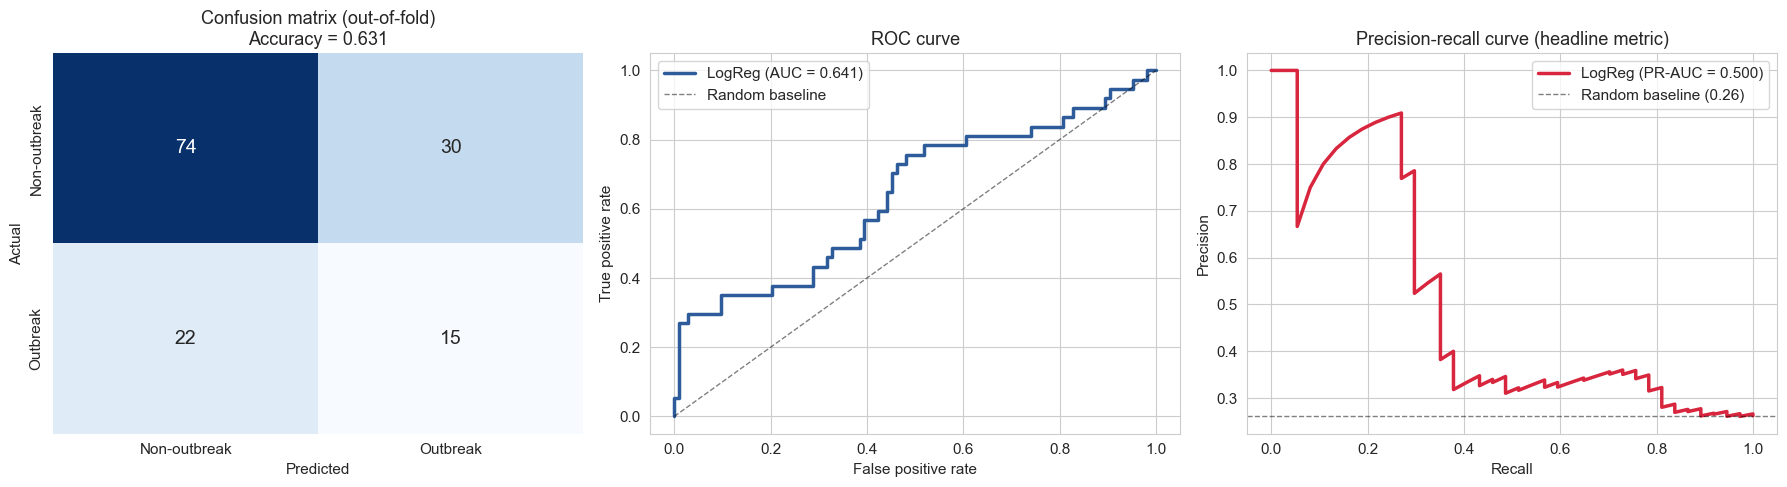

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
ax = axes[0]
cm = confusion_matrix(y, oof_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Non-outbreak', 'Outbreak'],
            yticklabels=['Non-outbreak', 'Outbreak'],
            cbar=False, annot_kws={'size': 14})
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion matrix (out-of-fold)\nAccuracy = {metrics["accuracy"]:.3f}')

# ROC
ax = axes[1]
fpr, tpr, _ = roc_curve(y, oof_proba)
ax.plot(fpr, tpr, color='#2E5C9A', linewidth=2.5, label=f'LogReg (AUC = {metrics["roc_auc"]:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random baseline')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curve')
ax.legend()

# PR
ax = axes[2]
prec, rec, _ = precision_recall_curve(y, oof_proba)
ax.plot(rec, prec, color='#D7263D', linewidth=2.5, label=f'LogReg (PR-AUC = {metrics["pr_auc"]:.3f})')
ax.axhline(positive_rate, color='black', linestyle='--', linewidth=1, alpha=0.5,
           label=f'Random baseline ({positive_rate:.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-recall curve (headline metric)')
ax.legend()

plt.tight_layout()
plt.show()

**Interpretation**

- **Confusion matrix** — diagonal entries are correct predictions; off-diagonal are errors
- **ROC** — measures rank ordering of predictions across all thresholds. AUC > 0.5 = better than random
- **PR curve** — under class imbalance, PR is more informative than ROC. We want high precision *and* high recall

The PR curve being well above the random baseline indicates the model can identify outbreak counties without flooding predictions with false positives.

## 7. Calibration — Are Probabilities Trustworthy?

Critical for the SIR simulation: if we use predicted P(outbreak) as a transmission-rate modifier, those probabilities need to mean what they say. A "30% probability" county should actually have flu in 30% of similar scenarios.

**Brier score** measures squared error of probabilities (lower = better; 0 = perfect; 0.25 = random for balanced classes).

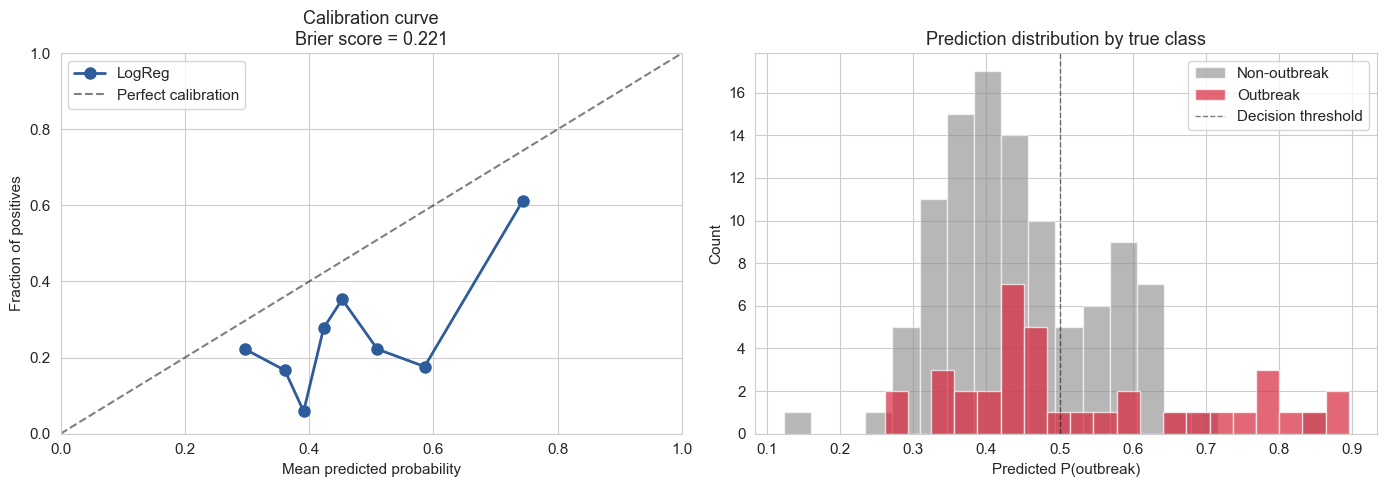

Calibration:
  Brier score:           0.221
  (0 = perfect, 0.25 = random for 50/50 class balance)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calibration curve
ax = axes[0]
prob_true, prob_pred = calibration_curve(y, oof_proba, n_bins=8, strategy='quantile')
ax.plot(prob_pred, prob_true, marker='o', color='#2E5C9A', linewidth=2,
        markersize=8, label='LogReg')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title(f'Calibration curve\nBrier score = {metrics["brier"]:.3f}')
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Prediction distribution by class
ax = axes[1]
ax.hist(oof_proba[y == 0], bins=20, alpha=0.6, color='#888888', label='Non-outbreak', edgecolor='white')
ax.hist(oof_proba[y == 1], bins=20, alpha=0.7, color='#D7263D', label='Outbreak', edgecolor='white')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Decision threshold')
ax.set_xlabel('Predicted P(outbreak)')
ax.set_ylabel('Count')
ax.set_title('Prediction distribution by true class')
ax.legend()

plt.tight_layout()
plt.show()

print(f'Calibration:')
print(f'  Brier score:           {metrics["brier"]:.3f}')
print(f'  (0 = perfect, 0.25 = random for 50/50 class balance)')

## 8. Bootstrap Coefficient Confidence Intervals

Notebook 03 flagged multicollinearity as a concern (4 features in the urban-diversity cluster). Logistic regression coefficients can be unstable in the presence of multicollinearity. We quantify this by **bootstrap resampling** — refit on 1000 random samples (with replacement), and look at the distribution of each coefficient.

A feature whose CI crosses zero has unstable sign — its true effect is uncertain.

In [9]:
N_BOOTSTRAP = 1000
rng = np.random.default_rng(42)

bootstrap_coefs = np.zeros((N_BOOTSTRAP, X.shape[1]))

for b in range(N_BOOTSTRAP):
    idx = rng.choice(len(y), size=len(y), replace=True)
    # Skip if a class is missing in the bootstrap sample
    if len(np.unique(y[idx])) < 2:
        bootstrap_coefs[b] = np.nan
        continue
    boot_model = LogisticRegression(
        C=model.C_[0], penalty='l2', solver='lbfgs',
        class_weight='balanced', max_iter=2000, random_state=42
    )
    boot_model.fit(X.iloc[idx], y[idx])
    bootstrap_coefs[b] = boot_model.coef_[0]

# Summary stats
boot_df = pd.DataFrame({
    'feature': X.columns,
    'point_estimate': model.coef_[0],
    'mean': np.nanmean(bootstrap_coefs, axis=0),
    'std': np.nanstd(bootstrap_coefs, axis=0),
    'ci_lower': np.nanpercentile(bootstrap_coefs, 2.5, axis=0),
    'ci_upper': np.nanpercentile(bootstrap_coefs, 97.5, axis=0),
})
boot_df['stable'] = (boot_df['ci_lower'] * boot_df['ci_upper'] > 0)  # CI doesn't cross zero

print('Bootstrap coefficient analysis (1000 resamples):\n')
boot_df_display = boot_df.copy()
for col in ['point_estimate', 'mean', 'std', 'ci_lower', 'ci_upper']:
    boot_df_display[col] = boot_df_display[col].round(3)
print(boot_df_display.to_string(index=False))

n_stable = boot_df['stable'].sum()
print(f'\n{n_stable}/{len(boot_df)} coefficients have CIs that do NOT cross zero (stable sign)')

Bootstrap coefficient analysis (1000 resamples):

             feature  point_estimate   mean   std  ci_lower  ci_upper  stable
pop_density_per_sqmi          -0.151 -0.134 0.090    -0.292     0.067   False
         pct_elderly          -0.064 -0.065 0.163    -0.360     0.247   False
  avg_household_size           0.419  0.431 0.123     0.197     0.678    True
       median_income           0.092  0.087 0.118    -0.147     0.308   False
public_transport_pct           0.045  0.053 0.099    -0.143     0.239   False
  pct_bachelors_plus          -0.296 -0.288 0.123    -0.517    -0.044    True
       pct_non_white           0.104  0.099 0.117    -0.138     0.321   False
    pct_foreign_born           0.284  0.281 0.086     0.121     0.454    True
            state_DE          -0.001 -0.004 0.061    -0.124     0.125   False
            state_NY          -0.120 -0.128 0.137    -0.390     0.129   False
            state_PA           0.088  0.098 0.133    -0.163     0.360   False

3/11 coeffici

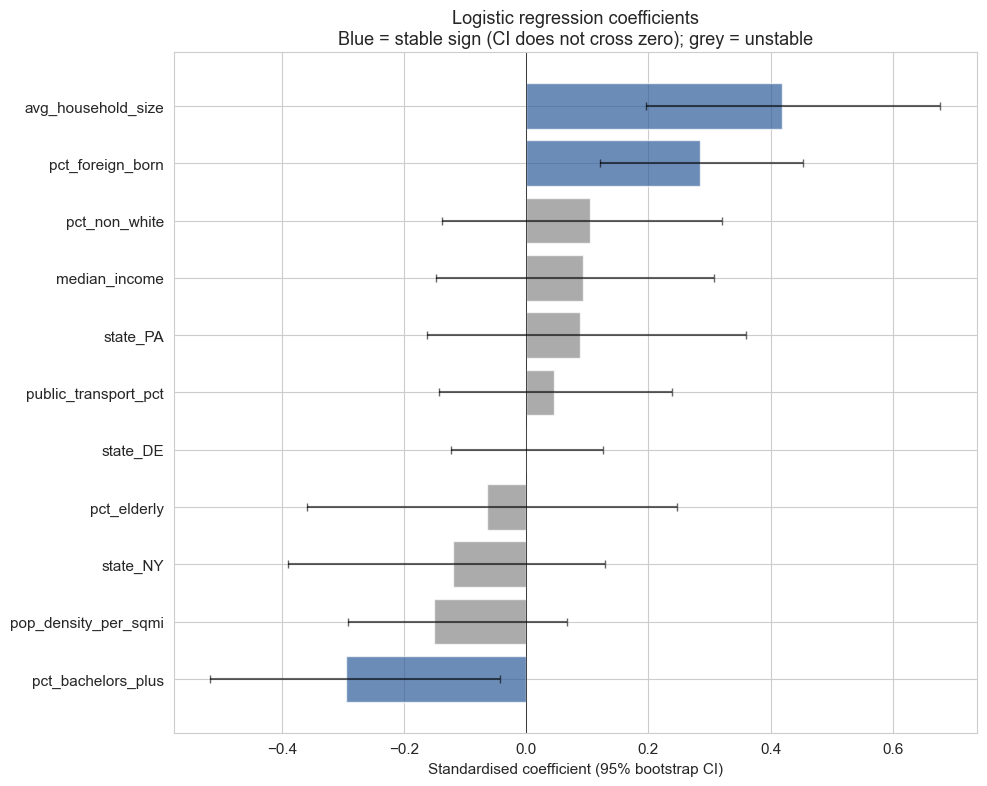

In [10]:
# Visualise: coefficients with bootstrap CIs
fig, ax = plt.subplots(figsize=(10, 8))

boot_df_sorted = boot_df.sort_values('point_estimate')
y_pos = range(len(boot_df_sorted))

# Colour by stability
colors = ['#2E5C9A' if s else '#888888' for s in boot_df_sorted['stable']]

ax.barh(y_pos, boot_df_sorted['point_estimate'], color=colors, alpha=0.7,
        xerr=[boot_df_sorted['point_estimate'] - boot_df_sorted['ci_lower'],
              boot_df_sorted['ci_upper'] - boot_df_sorted['point_estimate']],
        error_kw={'ecolor': 'black', 'capsize': 3, 'alpha': 0.6}, edgecolor='white')

ax.set_yticks(list(y_pos))
ax.set_yticklabels(boot_df_sorted['feature'])
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Standardised coefficient (95% bootstrap CI)')
ax.set_title('Logistic regression coefficients\nBlue = stable sign (CI does not cross zero); grey = unstable')
plt.tight_layout()
plt.show()

**Interpretation**

- **Blue bars** (stable sign): the feature's effect direction is consistent across 1000 bootstrap resamples. We can trust the sign.
- **Grey bars** (unstable sign): the CI crosses zero — the feature's coefficient could go either direction depending on the sample. We should not over-interpret these.

If many features are grey, it confirms the multicollinearity concern from Notebook 03 and suggests downstream models (Random Forest, XGBoost) may extract more reliable signal.

## 9. Per-State Performance Sanity Check

A model that does well on aggregate but fails on a subset of states is brittle. We split out-of-fold predictions by state.

In [11]:
per_state = pd.DataFrame({
    'fips': master['fips'],
    'state': master['state'],
    'county': master['county'],
    'true': y,
    'pred': oof_pred,
    'proba': oof_proba,
})

state_perf = per_state.groupby('state').apply(lambda g: pd.Series({
    'n': len(g),
    'positives': g['true'].sum(),
    'predicted_positives': g['pred'].sum(),
    'accuracy': accuracy_score(g['true'], g['pred']),
    'pr_auc': average_precision_score(g['true'], g['proba']) if g['true'].sum() > 0 else np.nan,
}), include_groups=False).round(3)

print('Performance by state (out-of-fold):\n')
print(state_perf.to_string())

Performance by state (out-of-fold):

          n  positives  predicted_positives  accuracy  pr_auc
state                                                        
CT      9.0        3.0                  5.0     0.333   0.554
DE      3.0        1.0                  2.0     0.667   1.000
NY     62.0       16.0                 15.0     0.823   0.682
PA     67.0       17.0                 23.0     0.493   0.318


## 10. Save Model Artifact + Metrics

In [12]:
# Save full model artifact
artifact = {
    'model': model,
    'scaler': scaler,
    'feature_names': list(X.columns),
    'demographic_features': DEMOGRAPHIC_FEATURES,
    'state_features': STATE_FEATURES,
    'best_C': float(model.C_[0]),
    'metrics': metrics,
    'coefficients': boot_df.to_dict(orient='records'),
}

with open(MODELS_DIR / 'lr_model.pkl', 'wb') as f:
    pickle.dump(artifact, f)
print(f'✅ Saved: {(MODELS_DIR / "lr_model.pkl").relative_to(PROJECT_ROOT)}')

# Also save metrics as JSON for easy comparison in Notebook 08
metrics_export = {
    'model': 'LogisticRegression',
    'best_C': float(model.C_[0]),
    'penalty': 'l2',
    'class_weight': 'balanced',
    'cv_metrics': {k: float(v) for k, v in metrics.items()},
    'baseline_pr_auc': float(positive_rate),
    'coefficients': [
        {
            'feature': str(row['feature']),
            'point_estimate': float(row['point_estimate']),
            'mean': float(row['mean']),
            'ci_95_lower': float(row['ci_lower']),
            'ci_95_upper': float(row['ci_upper']),
            'stable_sign': bool(row['stable']),
        }
        for _, row in boot_df.iterrows()
    ],
    'per_state_performance': state_perf.to_dict(orient='index'),
    'n_observations': int(len(y)),
    'n_features': int(X.shape[1]),
    'positive_class_rate': float(y.mean()),
}

with open(MODELS_DIR / 'lr_metrics.json', 'w') as f:
    json.dump(metrics_export, f, indent=2)
print(f'✅ Saved: {(MODELS_DIR / "lr_metrics.json").relative_to(PROJECT_ROOT)}')

✅ Saved: models/lr_model.pkl
✅ Saved: models/lr_metrics.json


## 11. Summary

In [13]:
print('=== Logistic Regression Summary ===\n')

print(f'Headline performance (cross-validated):')
print(f'  PR-AUC:    {metrics["pr_auc"]:.3f}  (random baseline: {positive_rate:.3f})')
print(f'  ROC-AUC:   {metrics["roc_auc"]:.3f}')
print(f'  Accuracy:  {metrics["accuracy"]:.3f}  (always-zero baseline: {1-positive_rate:.3f})')
print(f'  F1:        {metrics["f1"]:.3f}')
print(f'  Brier:     {metrics["brier"]:.3f}')

print(f'\nModel:')
print(f'  Selected C: {model.C_[0]:.4f}')
print(f'  Features:  {X.shape[1]} (8 demographic + 3 state)')
print(f'  Sample size: {len(y)} areas')
print(f'  Class weight: balanced')

print(f'\nCoefficient stability:')
print(f'  Stable (sign unambiguous): {n_stable}/{len(boot_df)}')

print(f'\n👉 Next: Notebook 05 (Random Forest), Notebook 06 (XGBoost), Notebook 07 (KNN), then Notebook 08 (comparison).')
print(f'\nLogReg artifact saved to models/lr_model.pkl for the comparison notebook.')

=== Logistic Regression Summary ===

Headline performance (cross-validated):
  PR-AUC:    0.500  (random baseline: 0.262)
  ROC-AUC:   0.641
  Accuracy:  0.631  (always-zero baseline: 0.738)
  F1:        0.366
  Brier:     0.221

Model:
  Selected C: 0.0886
  Features:  11 (8 demographic + 3 state)
  Sample size: 141 areas
  Class weight: balanced

Coefficient stability:
  Stable (sign unambiguous): 3/11

👉 Next: Notebook 05 (Random Forest), Notebook 06 (XGBoost), Notebook 07 (KNN), then Notebook 08 (comparison).

LogReg artifact saved to models/lr_model.pkl for the comparison notebook.
